# Fresh Eyes on CMIP Data Workshop 2026: Applications of CMIP6 data.
## Create climate stripes by downloading CMIP6 data using ESGF-API

### Import all relevant modules

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import numpy as np
import cartopy.crs as ccrs


In [ ]:
fn = '/home/galytska/Fresh_eyes/online_seminar/input_data/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/historical/r1i1p1f1/Amon/tas/gn/v20191108/'
ds = xr.open_dataset(fn + 'tas_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_185001-201412.nc')


### Some examples of data processing

In [ ]:
# Convert Temperature to °C
tas = ds.tas - 273.15

# for calculating anomalies: 

# Define the reference period 
#reference period is defined based on https://www.nature.com/articles/s43247-022-00498-3 (See Fig. 1a)
tas_ref = tas.sel(time=slice('1981-01-01', '2010-12-31'))

# Calculate monthly climatology for the reference period
tas_clim = tas_ref.groupby('time.month').mean('time')

# Monthly temperature anomalies relative to 1981–2010
tas_anom = tas.groupby('time.month') - tas_clim

# Select the period to analyze
tas_anom = tas_anom.sel(time=slice('1979-01-01', '2014-12-31'))


Text(0.5, 1.0, 'Near-Surface Air Temperature Anomalies')

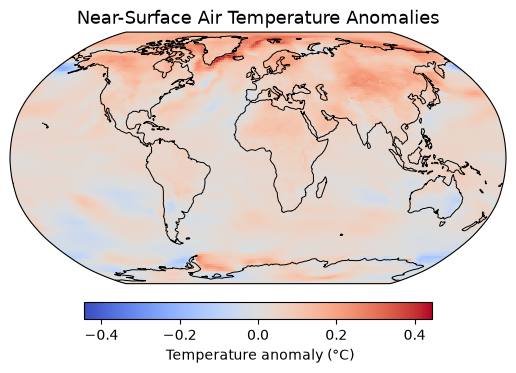

In [20]:
# Map
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

tas_anom.mean("time").plot(
    ax=axis,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    # vmin=-5,
    # vmax=5,
    cbar_kwargs={
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.05,
        "label": " Temperature anomaly (°C)"
    }
)

axis.coastlines(linewidth=0.7)
axis.set_global()
axis.set_title("Near-Surface Air Temperature Anomalies", fontsize=13)

### Lets now have a look closer at the Arctic region, 65-90 N 

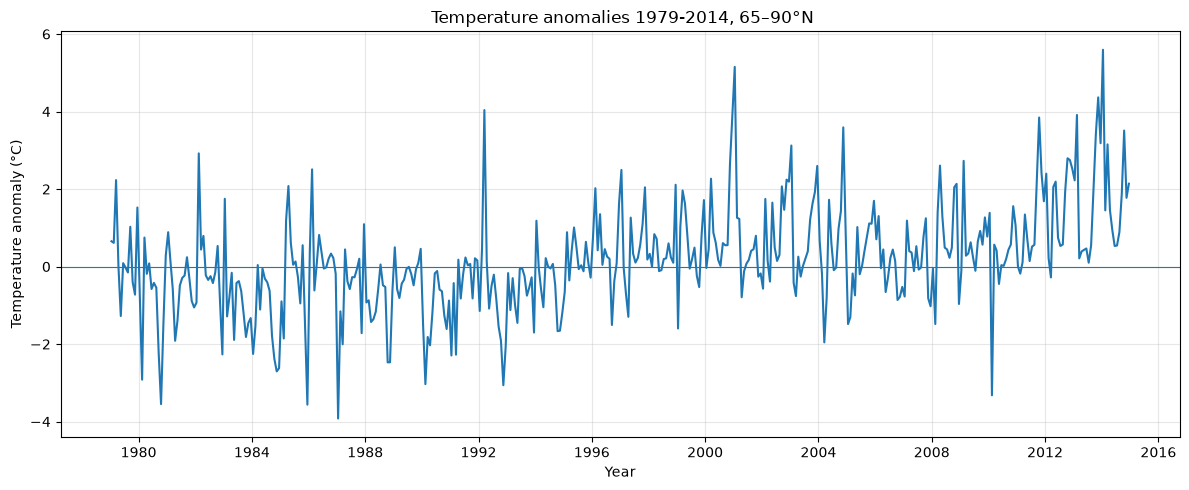

In [21]:

# Select regional mean 65–90°N
tas_65_90N = tas_anom.sel(lat=slice(65, 90)).mean(dim=['lat', 'lon'])


# Plot
plt.figure(figsize=(12, 5))

plt.plot(
    tas_65_90N.time,
    tas_65_90N,
    linewidth=1.5
)

plt.axhline(0, linewidth=0.8)

plt.xlabel('Year')
plt.ylabel('Temperature anomaly (°C)')
plt.title(' Temperature anomalies 1979-2014, 65–90°N')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Let's transform the line plot to climate stripes.

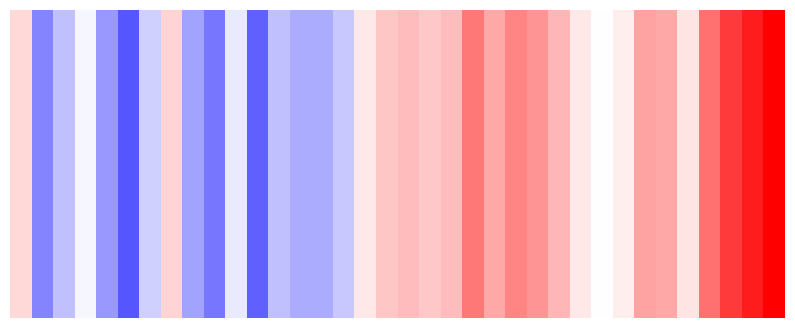

In [ ]:
# 
tas_65_90N_yearly = tas_65_90N.groupby('time.year').mean('time')


temperature = tas_65_90N_yearly 


nx = len(temperature)
x = np.arange(len(temperature))
y = np.array([0, 1])
temperature = np.vstack([temperature, temperature])

cmap = 'bwr' # I suggest "bwr" so I the plots look really identical with ESMvalTool (it is not easy to define the colormap in ESMValTool)

limit = np.nanmax(np.abs(temperature))

norm = mpl.colors.Normalize(vmin=-limit,vmax=limit)

figure, axes = plt.subplots(figsize=(10, 4))
axes.pcolormesh(x, y, temperature, cmap=cmap, norm=norm, shading='auto')
axes.set_axis_off()